# Segmentacja abonentów telekomunikacyjnych metodą k-średnich

## Streszczenie

Operator telekomunikacyjny chce podzielić swoją bazę abonentów postpaid na segmenty behawioralne, aby trafnie kierować oferty retencyjne i dobierać wielkość pakietów danych. Ten notebook generuje syntetyczny zbiór danych o użyciu abonentów, a następnie uruchamia pełny proces segmentacji metodą k-średnich w Base SAS: standaryzuje zmienne użycia za pomocą **PROC STDIZE**, wybiera liczbę klastrów, porównując statystykę pseudo-F dla kandydackich wartości k za pomocą **PROC FASTCLUS**, dopasowuje końcowy model ważony częstością (FREQ), który ocenia każdego abonenta, i eksportuje wyuczone centroidy, dzięki czemu migawkę z przyszłego miesiąca można ocenić bez ponownego klastrowania. Wynikiem jest wielokrotnego użytku segmentacja, która przekłada surową telemetrię użycia na plan działań retencyjnych.

## Źródła danych

**Zbiór syntetyczny: `WORK.SUBSCRIBERS`** (100 abonentów mobilnych postpaid, wygenerowanych w locie za pomocą `call streaminit(20260531)`)

| Zmienna | Typ | Rola | Opis |
|----------|------|------|-------------|
| `cust_id` | Znakowa | ID | Identyfikator abonenta (np. `SUB000123`) |
| `tenure_months` | Liczbowa | Zmienna wejściowa ciągła | Liczba miesięcy aktywności linii (1-72) |
| `data_gb` | Liczbowa | Zmienna wejściowa ciągła | Średnie miesięczne zużycie danych mobilnych, w GB |
| `voice_min` | Liczbowa | Zmienna wejściowa ciągła | Średnia miesięczna liczba minut rozmów |
| `intl_min` | Liczbowa | Zmienna wejściowa ciągła | Średnia miesięczna liczba minut połączeń międzynarodowych |
| `support_calls` | Liczbowa | Zmienna wejściowa ciągła | Kontakty z obsługą klienta w ostatnich 90 dniach |
| `monthly_charge` | Liczbowa | Zmienna wejściowa ciągła | Bieżący rachunek miesięczny, w dolarach |
| `plan_tier` | Znakowa | Profilowanie | Taryfa: `Podstawowa`, `Plus` lub `Nielimitowany` |
| `n_lines` | Liczbowa | Waga FREQ | Liczba linii na koncie |

W generatorze osadzone są trzy ukryte profile behawioralne - *lekki/oszczędny*, *intensywne dane/streaming* oraz *wymagający kontaktu/zagrożony odejściem* - dzięki czemu klastrowanie ma rzeczywistą strukturę do odkrycia. Zmienne ciągłe zasilają model k-średnich; `plan_tier` jest wyłączona z klastrowania i służy do profilowania po fakcie, a `n_lines` waży każde konto liczbą jego linii. Nie są używane żadne pliki zewnętrzne ani dostęp do sieci.

## Segmentacja behawioralna w pięciu krokach

Operatorzy mobilni obsługują miliony linii postpaid, a jedna uniwersalna strategia retencyjna marnuje marżę na klientach, którzy i tak by zostali, jednocześnie pomijając tych bliskich rezygnacji. **Segmentacja behawioralna** przekształca surową telemetrię użycia w garść praktycznych typów klientów: użytkowników *lekki/oszczędny*, wrażliwych na cenę, *intensywnych użytkowników danych/streamingu*, dobrych kandydatów do up-sellingu, oraz konta *wymagające kontaktu/zagrożone odejściem*, potrzebujące proaktywnej opieki.

Ten notebook buduje segmentację za pomocą `PROC FASTCLUS`, procedury k-średnich (rozłącznego klastrowania) SAS. Wykonamy:

1. Wygenerowanie syntetycznego, lecz realistycznego zbioru danych o użyciu abonentów.
2. Sprowadzenie zmiennych użycia do wspólnej skali za pomocą **PROC STDIZE**.
3. **Wybór liczby klastrów** poprzez porównanie statystyki pseudo-F dla kandydackich wartości k.
4. Dopasowanie końcowego modelu ważonego FREQ, który **ocenia** każdego abonenta i profiluje segmenty.
5. **Eksport wyuczonych centroidów**, aby model można było ponownie zastosować do migawki z przyszłego miesiąca.

## Krok 1 - Wygenerowanie syntetycznej bazy abonentów

Symulujemy 100 abonentów postpaid. Każdy jest losowany z jednego z trzech ukrytych profili o różnej charakterystyce użycia, dzięki czemu istnieje rzeczywista struktura klastrów do odkrycia. Ustalamy strumień losowy za pomocą `call streaminit`, aby zapewnić powtarzalność, i ograniczamy symulowane wartości do wiarygodnych zakresów za pomocą `max`/`min`/`round`.

Zmienna nominalna `plan_tier` jest skorelowana z ukrytym profilem (użytkownicy streamingu skłaniają się ku taryfie *Nielimitowany*; użytkownicy oszczędni ku *Podstawowa*), a `n_lines` posłuży później jako waga FREQ, dzięki czemu konta rodzinne z wieloma liniami liczą się proporcjonalnie.

In [1]:
DANE subscribers;
    CALL streaminit(20260531);
    DŁUGOŚĆ cust_id $9 plan_tier $16;
    POWTÓRZ i = 1 TO 100;
        cust_id = cats('SUB', ZAPISZ(i, z6.));

        /* Trzy ukryte profile behawioralne, ~nierowne rozpowszechnienie */
        u = rand('uniform');
        JEŚLI u < 0.45 WTEDY profile = 1;        /* lekki / oszczędny        */
        PRZECIWNIE JEŚLI u < 0.80 WTEDY profile = 2;   /* intensywne dane / streaming   */
        PRZECIWNIE profile = 3;                    /* wymagający kontaktu / zagrożony  */

        JEŚLI profile = 1 WTEDY POWTÓRZ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        KONIEC;
        PRZECIWNIE JEŚLI profile = 2 WTEDY POWTÓRZ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        KONIEC;

        /* Taryfa skorelowana z profilem */
        p = rand('uniform');
        JEŚLI profile = 1 WTEDY
            plan_tier = ifc(p < 0.70, 'Podstawowa', ifc(p < 0.95, 'Plus', 'Nielimitowany'));
        PRZECIWNIE JEŚLI profile = 2 WTEDY
            plan_tier = ifc(p < 0.65, 'Nielimitowany', ifc(p < 0.90, 'Plus', 'Podstawowa'));
        PRZECIWNIE
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Nielimitowany', 'Podstawowa'));

        /* Liczba linii na koncie: większość to pojedyncze linie */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Zaokrąglenie wartości pieniężnych / użycia do realistycznej precyzji */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        WYJŚCIE;
    KONIEC;
    USUŃ i u p profile;
WYKONAJ;

PROCEDURA DRUKUJ DANE=subscribers(obs=10) noobs;
    ETYKIETA cust_id="ID klienta" tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)" plan_tier="Taryfa" n_lines="Liczba linii";
    TYTUŁ 'Próbka syntetycznych rekordów użycia abonentów';
WYKONAJ;

                                     Próbka syntetycznych rekordów użycia abonentów                                     

ID klienta         Taryfa   Staż (mies.)  Dane (GB)   Minuty rozmów   Minuty międzynarodowe   Zgłoszenia serwisowe    Opłata miesięczna ($)  Liczba linii
SUB000001   Podstawowa                15        9.7             114                       5                     11                    57.07             2
SUB000002   Podstawowa                39        0.6             214                       2                      1                    35.88             3
SUB000003   Nielimitowany             45       23.9             325                       6                      1                   103.94             2
SUB000004   Podstawowa                41        1.9             202                       1                      0                    61.69             3
SUB000005   Podstawowa                34        2.8             112                       4                 


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Krok 2 - Sprowadzenie zmiennych do wspólnej skali

k-średnich wykorzystuje odległość euklidesową, więc zmienna o dużej skali, jak minuty rozmów, zdominowałaby zmienną o małej skali, jak liczba zgłoszeń serwisowych, gdybyśmy klastrowali na surowych wartościach. Standardowym remedium jest wcześniejsza standaryzacja każdej zmiennej ciągłej do średniej 0 i odchylenia standardowego 1. **PROC STDIZE** z `METHOD=STD` robi dokładnie to, zapisując wystandaryzowaną kopię do `WORK.SUBS_STD`. Przenosimy `cust_id`, `plan_tier` i `n_lines` bez zmian, aby były dostępne później do ważenia i profilowania.

In [2]:
PROCEDURA stdize DANE=subscribers out=subs_std METHOD=std;
    ZMIENNA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=subs_std mean std maxdec=3;
    ZMIENNA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETYKIETA tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)";
    TYTUŁ 'Standaryzowane zmienne: średnia ~ 0, odch. std ~ 1';
WYKONAJ;

                                     Próbka syntetycznych rekordów użycia abonentów                                     

                                   Standaryzowane zmienne: średnia ~ 0, odch. std ~ 1                                   

                                                  The MEANS Procedure

 Variable        Label                             Mean     Std Dev
 ------------------------------------------------------------------
 tenure_months   Staż (mies.)                     0.000       1.000
 data_gb         Dane (GB)                       -0.000       1.000
 voice_min       Minuty rozmów                   -0.000       1.000
 intl_min        Minuty międzynarodowe            0.000       1.000
 support_calls   Zgłoszenia serwisowe            -0.000       1.000
 monthly_charge  Opłata miesięczna ($)            0.000       1.000
 ------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 3 - Ile segmentów? Porównanie statystyki pseudo-F dla kandydackich k

Zamiast zgadywać liczbę klastrów, dopasowujemy FASTCLUS dla każdej kandydackiej wartości k i odczytujemy raportowane statystyki dopasowania modelu. Zarówno **statystyka pseudo-F** (stosunek wariancji międzyklastrowej do wewnątrzklastrowej), jak i **ogólne R-kwadrat** nagradzają separację; dobre k to takie, przy którym pseudo-F jest wysokie, a dodanie kolejnego klastra daje malejące korzyści. Krótka pętla makra uruchamia k = 2, 3, 4 z `MAXITER=50` i `CONVERGE=0` (iteracja do stabilizacji). Porównaj wiersze `Pseudo F Statistic` i `Overall R-Squared` w trzech poniższych zestawieniach: osadzona struktura ma trzy ukryte profile, a k = 3 daje najsilniejsze, najbardziej zrównoważone rozwiązanie.

In [3]:
%macro pick_k;
    %POWTÓRZ k = 2 %TO 4;
        PROCEDURA FASTCLUS DANE=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            ZMIENNA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            ETYKIETA tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)";
            TYTUŁ "Kandydacka liczba klastrów: k = &k";
        WYKONAJ;
    %KONIEC;
%mend pick_k;
%pick_k;

                                   Standaryzowane zmienne: średnia ~ 0, odch. std ~ 1                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Krok 4 - Dopasowanie ostatecznej segmentacji i ocena każdego abonenta

Po wybraniu k = 3 dopasowujemy model produkcyjny. Ten przebieg jest w pełni typowy dla segmentacji operacyjnej:

- Instrukcja `FREQ` waży każde konto przez `n_lines`, więc konto rodzinne z czterema liniami wnosi czterokrotnie więcej niż pojedyncza linia przy obliczaniu centroidów.
- `OUT=SCORED` zapisuje każdego abonenta wraz z przypisanym `CLUSTER` i jego `DISTANCE` do centroidu tego klastra; instrukcja `ID` przenosi `cust_id` do tej ocenionej tabeli.
- `MEAN=SEG_MEANS` przechwytuje centroidy dla każdego klastra (w skali standaryzowanej).
- `OUTSEED=SEG_SEEDS` zapisuje ostateczne centroidy w formacie ziaren, który FASTCLUS może odczytać ponownie - to jest wyeksportowany model, który ponownie zastosujemy w Kroku 6.

Statystyki dopasowania modelu zostały już ustalone w przeglądzie z Kroku 3, więc dodajemy tutaj opcję `SHORT`, aby zestawienie skupiało się na wielkościach klastrów i centroidach, które napędzają wynik oceny.

In [4]:
PROCEDURA FASTCLUS DANE=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    ZMIENNA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    CZĘSTOŚCI n_lines;
    id cust_id;
    ETYKIETA tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)" cust_id="ID klienta";
    TYTUŁ 'Segmentacja końcowa: k = 3, ważona liczbą linii (FREQ)';
WYKONAJ;

PROCEDURA DRUKUJ DANE=seg_means noobs;
    ETYKIETA tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)" CLUSTER="Segment";
    TYTUŁ 'Centroidy segmentów (skala standaryzowana)';
WYKONAJ;

                                   Standaryzowane zmienne: średnia ~ 0, odch. std ~ 1                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Krok 5 - Profilowanie segmentów w jednostkach biznesowych

Oceniona tabela zawiera przypisanie `CLUSTER` każdego abonenta, ale w skali standaryzowanej centroidy są trudne do odczytania. Aby przekształcić numery klastrów w persony biznesowe, łączymy przypisanie z powrotem z oryginalną tabelą `subscribers` i profilujemy w rzeczywistych jednostkach - gigabajtach, minutach i dolarach. PROC MEANS podsumowuje zmienne ciągłe według segmentu, a PROC FREQ krzyżuje wyłączoną wcześniej `plan_tier` z segmentem, aby pokazać strukturę taryf każdej persony.

                          Profile segmentów: średnie użycie wg klastra (jednostki oryginalne)                           

                                                  The MEANS Procedure

                                   Analysis Variable : tenure_months Staż (mies.)

                                         N
                            Segment    Obs      Mean      Std Dev      Minimum      Maximum
                            ---------------------------------------------------------------
                            1           51      33.2         14.7          1.0         61.0
                            2           31      40.5         14.0         17.0         67.0
                            3           18      12.7          7.1          1.0         30.0
                            ---------------------------------------------------------------

                                        Analysis Variable : data_gb Dane (GB)

                                         N
      


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


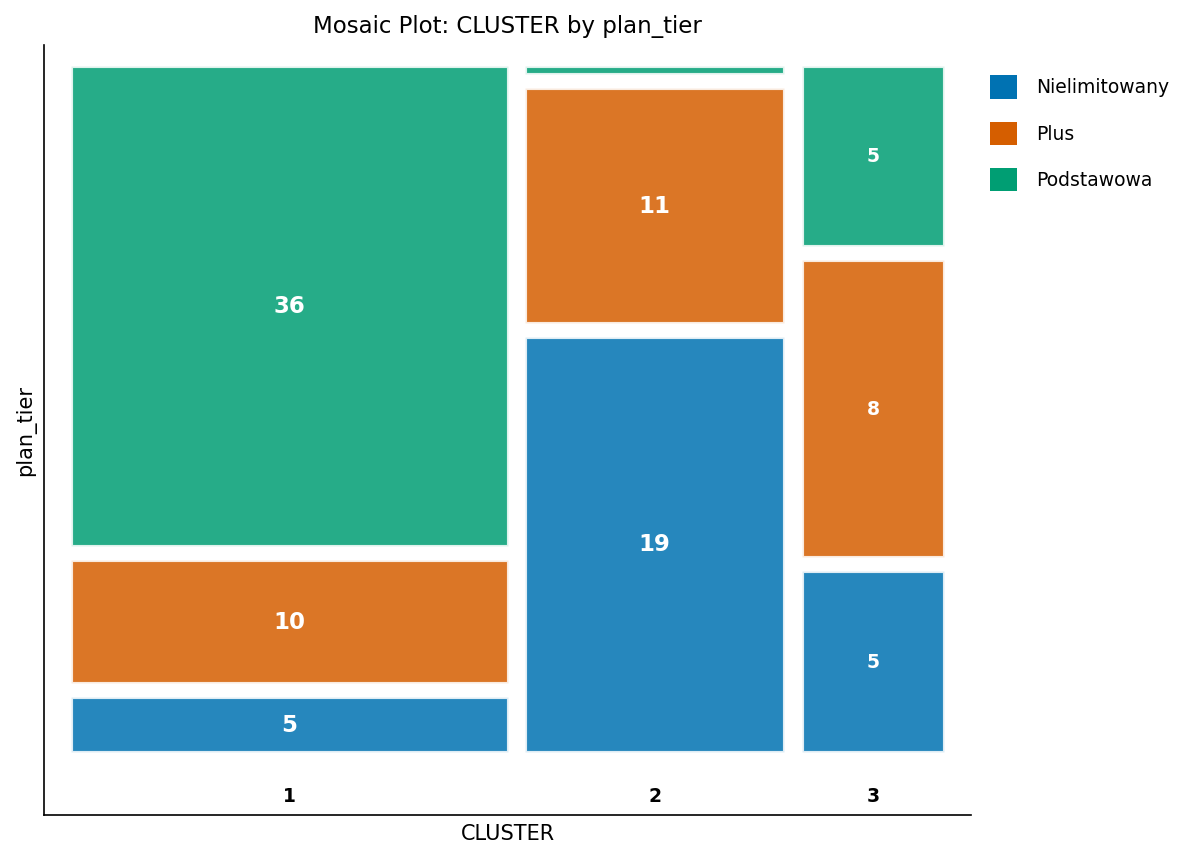

In [5]:
PROCEDURA SORTUJ DANE=scored out=scored_keys(ZACHOWAJ=cust_id CLUSTER);
    WEDŁUG cust_id;
WYKONAJ;

PROCEDURA SORTUJ DANE=subscribers out=subs_sorted;
    WEDŁUG cust_id;
WYKONAJ;

DANE profile;
    POŁĄCZ subs_sorted(IN=a) scored_keys(IN=b);
    WEDŁUG cust_id;
    JEŚLI a AND b;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=profile mean std MIN MAX maxdec=1;
    KLASA CLUSTER;
    ZMIENNA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETYKIETA CLUSTER="Segment" tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)";
    TYTUŁ 'Profile segmentów: średnie użycie wg klastra (jednostki oryginalne)';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    ETYKIETA CLUSTER="Segment" plan_tier="Taryfa";
    TYTUŁ 'Udział taryf w każdym segmencie';
WYKONAJ;

## Krok 6 - Ponowne zastosowanie modelu do migawki z przyszłego miesiąca

Segmentacja jest użyteczna tylko wtedy, gdy można ją ponownie zastosować bez ponownego uruchamiania całego zadania. Centroidy zapisane do `SEG_SEEDS` w Kroku 4 stanowią przenośny model: podanie ich z powrotem jako `SEED=SEG_SEEDS` z `MAXITER=0` nakazuje FASTCLUS *przypisać* każdą obserwację do najbliższego zapisanego centroidu bez przesuwania centroidów - czyste wynikowanie, a nie ponowne dopasowanie. Tutaj ponownie oceniamy tę samą standaryzowaną migawkę, aby potwierdzić, że wyeksportowany model odtwarza oryginalne przypisania; w produkcji `DATA=` wskazywałoby zamiast tego na standaryzowaną migawkę z przyszłego miesiąca.

                                            Udział taryf w każdym segmencie                                             


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


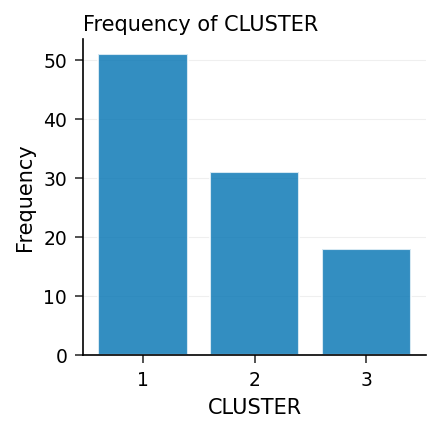

In [6]:
PROCEDURA FASTCLUS DANE=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    ZMIENNA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    ETYKIETA tenure_months="Staż (mies.)" data_gb="Dane (GB)" voice_min="Minuty rozmów" intl_min="Minuty międzynarodowe" support_calls="Zgłoszenia serwisowe" monthly_charge="Opłata miesięczna ($)" cust_id="ID klienta";
    TYTUŁ 'Wynikowanie nowego zrzutu na podstawie wyeksportowanych centroidów';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=rescored;
    TABLES CLUSTER / nocum;
    ETYKIETA CLUSTER="Segment";
    TYTUŁ 'Abonenci ponownie ocenieni przy użyciu wyeksportowanego modelu';
WYKONAJ;

## Interpretacja wyników

FASTCLUS odtworzył trzy segmenty behawioralne osadzone w danych, a tabele profilujące przekładają je na plan działań retencyjnych. Odczytaj numery segmentów z powyższej tabeli *Profile segmentów* - etykiety klastrów są arbitralne, więc każdą personę identyfikuj po jej charakterystyce użycia:

- **Użytkownicy lekcy/oszczędni** - niskie zużycie danych, skromne rachunki, dłuższy staż, bardzo mało zgłoszeń serwisowych, głównie na taryfie *Podstawowa*. Ci klienci są stabilni i wrażliwi na cenę; właściwym ruchem jest *ochrona marży*, a nie rabaty. Rekomendacja odpowiednio dobranego pakietu zapobiega szokowi rachunkowemu bez rozdawania zniżek.
- **Intensywni użytkownicy danych/streamingu** - wysokie zużycie danych, dużo minut rozmów i połączeń międzynarodowych, wysokie rachunki, głównie *Nielimitowany*. Są lojalni i wysokowartościowi: strategią jest *up-selling i aktualizacje urządzeń*, a także proaktywna komunikacja o jakości sieci, aby oferta konkurencji nie mogła ich odciągnąć.
- **Wymagający kontaktu / zagrożeni odejściem** - krótki staż, podwyższona liczba zgłoszeń serwisowych, wydatki na średnim poziomie. Częste kontakty z obsługą w połączeniu z krótkim stażem to klasyczne zapowiedzi rezygnacji. To segment, który zasługuje na *proaktywną ofertę retencyjną* i działania naprawcze w obsłudze.

Kluczowe decyzje proceduralne, które to umożliwiły: **PROC STDIZE** nie pozwolił, aby wysoka skala minut rozmów zdominowała sygnał zgłoszeń serwisowych; przegląd pseudo-F uzasadnił liczbę klastrów zamiast jej zgadywania; waga `FREQ` sprawiła, że konta rodzinne z wieloma liniami liczyły się proporcjonalnie do swojej wielkości; a cykl `OUTSEED=`/`SEED=` wyeksportował centroidy, dzięki czemu zespół marketingu może ponownie segmentować każdą comiesięczną migawkę pojedynczym wywołaniem FASTCLUS z `MAXITER=0` - bez potrzeby ponownego klastrowania.